# Przetwarzanie wstępne. Filtracja kontekstowa.


### Cel:
- zapoznanie z pojęciem kontekstu / filtracji kontekstowej,
- zapoznanie z pojęciem konwolucji (splotu),
- zapoznanie z wybranymi filtrami:
	- filtry liniowe dolnoprzepustowe:
		- filtr uśredniający,
		- filtr Gaussa.
	- filtry nielinowe:
		- mediana,
		- mediana dla obrazów kolorowych.
	- filtry liniowe górnoprzepustowe:
			- laplasjan,
			- operator Robersta, Prewitta, Sobela.
- zadanie domowe: adaptacyjna filtracja medianowa.

### Filtry liniowe uśredniające (dolnoprzepustowe)

Jest to podstawowa rodzina filtrów stosowana w cyfrowym przetwarzaniu obrazów. 
Wykorzystuje się je w celu "rozmazania" obrazu i tym samym redukcji szumów (zakłóceń) na obrazie.
Filtr określony jest przez dwa parametry: rozmiar maski (ang. _kernel_) oraz wartości współczynników maski.

Warto zwrócić uwagę, że omawiane w niniejszym rozdziale operacje generują nową wartość piksela na podstawie pewnego fragmentu obrazu (tj. kontekstu), a nie jak operacje punktowe tylko na podstawie jednego piksela.


1. Wczytaj obraz _plansza.png_.
W dalszej części ćwiczenia sprawdzenie działania filtracji dla innych obrazów sprowadzi się do wczytania innego pliku.

2. Podstawowa funkcja to `cv2.filter2D`  - realizacja filtracji konwolucyjnej.
   Proszę sprawdzić jej dokumentację i zwrócić uwagę na obsługę problemu brzegowego (na krawędziach istnieją piksele dla których nie da się wyznaczyć otoczenia).

  Uwaga. Problem ten można też rozwiązać z użyciem funkcji `signal.convolve2d` z biblioteki _scipy_ (`from scipy import signal`).

3. Stwórz podstawowy filtr uśredniający o rozmiarze $3 \times 3$ -- za pomocą funkcji `np.ones`. Wykonaj konwolucję na wczytanym obrazie. Na wspólnym rysunku wyświetl obraz oryginalny, po filtracji oraz moduł z różnicy.

4. Przeanalizuj otrzymane wyniki. Jakie elementy zawiera obraz "moduł z różnicy"? Co na tej podstawie można powiedzieć o filtracji dolnoprzepustowej?

In [1]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np
from scipy import signal

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/06_Context/"

fileNames = ["jet.png", "kw.png", "moon.png", "lenaSzum.png", "lena.png", "plansza.png"]
for fileName in fileNames:
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, "wb").write(r.content)

images = {}
for fileName in fileNames:
    fileNameBase = ".".join(fileName.split(".")[:-1])
    images[fileNameBase] = cv2.imread(fileName, cv2.IMREAD_GRAYSCALE)

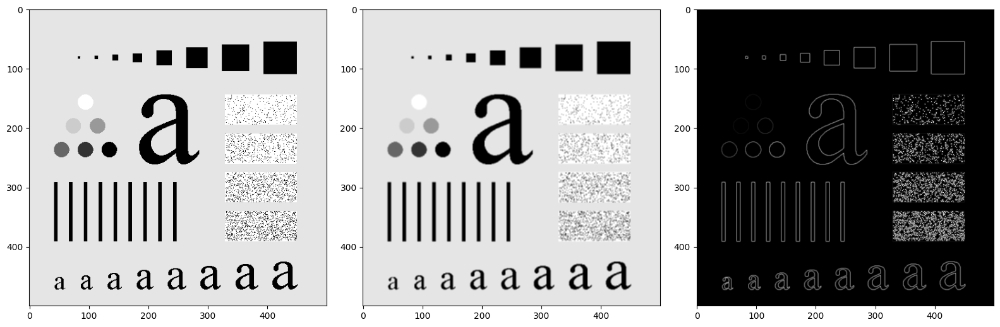

In [2]:
N = 3
image = images["plansza"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
kernel = np.ones((N, N), dtype=np.float64) / N**2
image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
image_diff = np.abs(
    cv2.subtract(image.astype("int16"), image_filtered.astype("int16"))
).astype("uint8")
axs[0].imshow(image, cmap="gray")
axs[1].imshow(image_filtered, cmap="gray")
axs[2].imshow(image_diff, cmap="gray")
plt.show()

5. Na wspólnym rysunku wyświetl wyniki filtracji uśredniającej z oknem o rozmiarze 3, 5, 9, 15 i 35. 
Wykorzystaj polecenie `plt.subplot`. 
Przeanalizuj wpływ rozmiaru maski na wynik. 

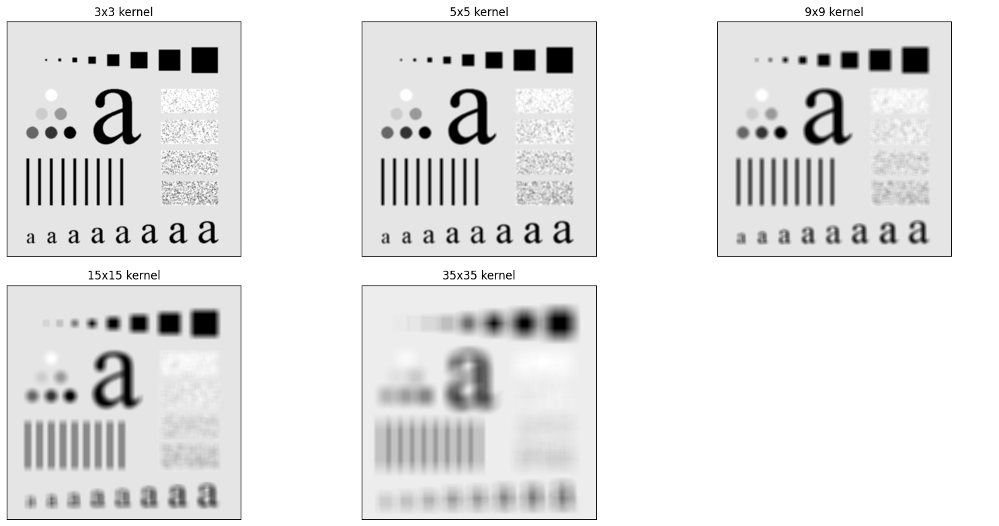

In [3]:
f, axs = plt.subplots(2, 3)
f.set_size_inches(16, 8)
f.tight_layout()
axs = axs.flatten()

for i, N in enumerate([3, 5, 9, 15, 35]):
    kernel = np.ones((N, N), dtype=np.float64) / N**2

    # output = signal.convolve2d(images["plansza"], kernel, boundary="symm")

    output = cv2.filter2D(
        src=images["plansza"], ddepth=-1, kernel=kernel, borderType=cv2.BORDER_DEFAULT
    )

    axs[i].imshow(output, cmap="gray")
    axs[i].set_title(f"{N}x{N} kernel")


for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
axs[5].axis("off")

plt.show()

6. Wczytaj obraz _lena.png_.
Zaobserwuj efekty filtracji dolnoprzepustowej dla obrazu rzeczywistego.

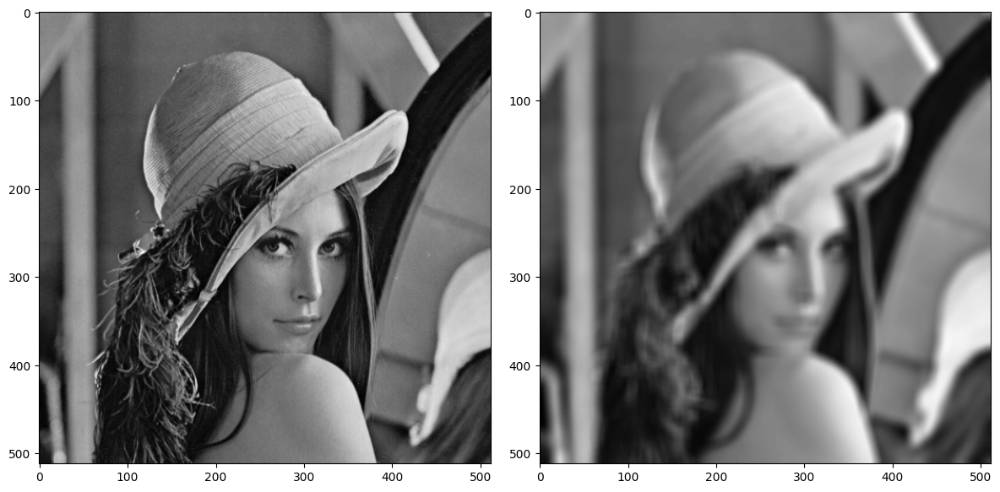

In [4]:
N = 13
image = images["lena"]

f, axs = plt.subplots(1, 2)
f.set_size_inches(12, 6)
f.tight_layout()
kernel = np.ones((N, N), dtype=np.float64) / N**2
image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
axs[0].imshow(image, cmap="gray")
axs[1].imshow(image_filtered, cmap="gray")
plt.show()

7. Niekorzystny efekt towarzyszący wykonanym filtracjom dolnoprzepustowym to utrata ostrości. 
Częściowo można go zniwelować poprzez odpowiedni dobór maski. 
Wykorzystaj maskę:  `M = np.array([1 2 1; 2 4 2; 1 2 1])`. 
Przed obliczeniami należy jeszcze wykonać normalizację - podzielić każdy element maski przez sumę wszystkich elementów: `M = M/sum(sum(M));`.
Tak przygotowaną maskę wykorzystaj w konwolucji - wyświetl wyniki tak jak wcześniej.
Możliwe jest też wykorzystywanie innych masek - współczynniki można dopasowywać do konkretnego problemu.

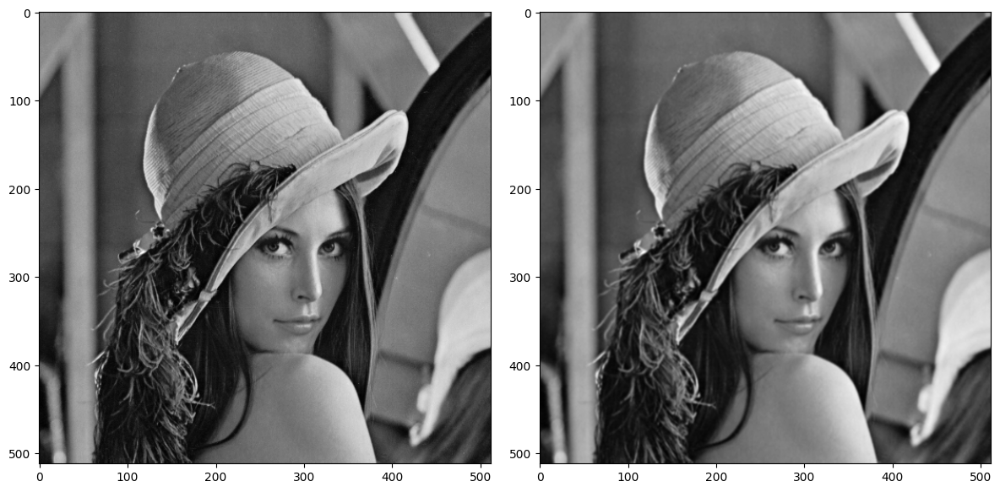

In [5]:
image = images["lena"]

f, axs = plt.subplots(1, 2)
f.set_size_inches(12, 6)
f.tight_layout()
kernel = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float64)
kernel = kernel / np.sum(kernel)
image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
axs[0].imshow(image, cmap="gray")
axs[1].imshow(image_filtered, cmap="gray")
plt.show()

8. Skuteczną i często wykorzystywaną maską jest tzw. maska Gasussa.
Jest to zbiór liczb, które aproksymują dwuwymiarowy rozkład Gaussa. 
Parametrem jest odchylenie standardowe i rozmiar maski.

9. Wykorzystując przygotowaną funkcję `fgaussian` stwórz maskę o rozmiarze $5 \times 5$ i odchyleniu standardowym 0.5.
  Wykorzystując funkcję `mesh` zwizualizuj filtr.
  Sprawdź jak parametr ``odchylenie standardowe'' wpływa na ``kształt'' filtru.

  Uwaga. W OpenCV dostępna jest *dedykowana* funkcja do filtracji Gaussa - `GaussianBlur`.
  Proszę na jednym przykładzie porównać jej działanie z użytym wyżej rozwiązaniem.

10. Wykonaj filtrację dla wybranych (2--3) wartości odchylenia standardowego.


In [6]:
def fgaussian(size, sigma):
    m = n = size
    h, k = m // 2, n // 2
    x, y = np.mgrid[-h : h + 1, -k : k + 1]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return g / g.sum()


def mesh(fun, size):
    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")

    X = np.arange(-size // 2, size // 2, 1)
    Y = np.arange(-size // 2, size // 2, 1)
    X, Y = np.meshgrid(X, Y)
    Z = fun

    ax.plot_surface(X, Y, Z)

    plt.show()

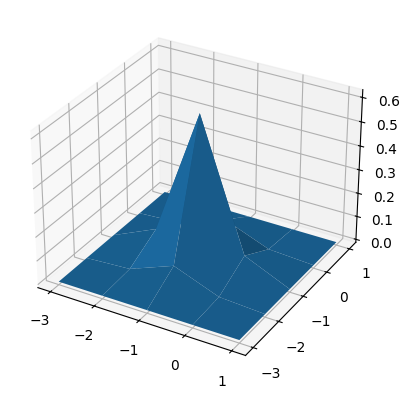

In [7]:
mesh(fgaussian(5, 0.5), 5)

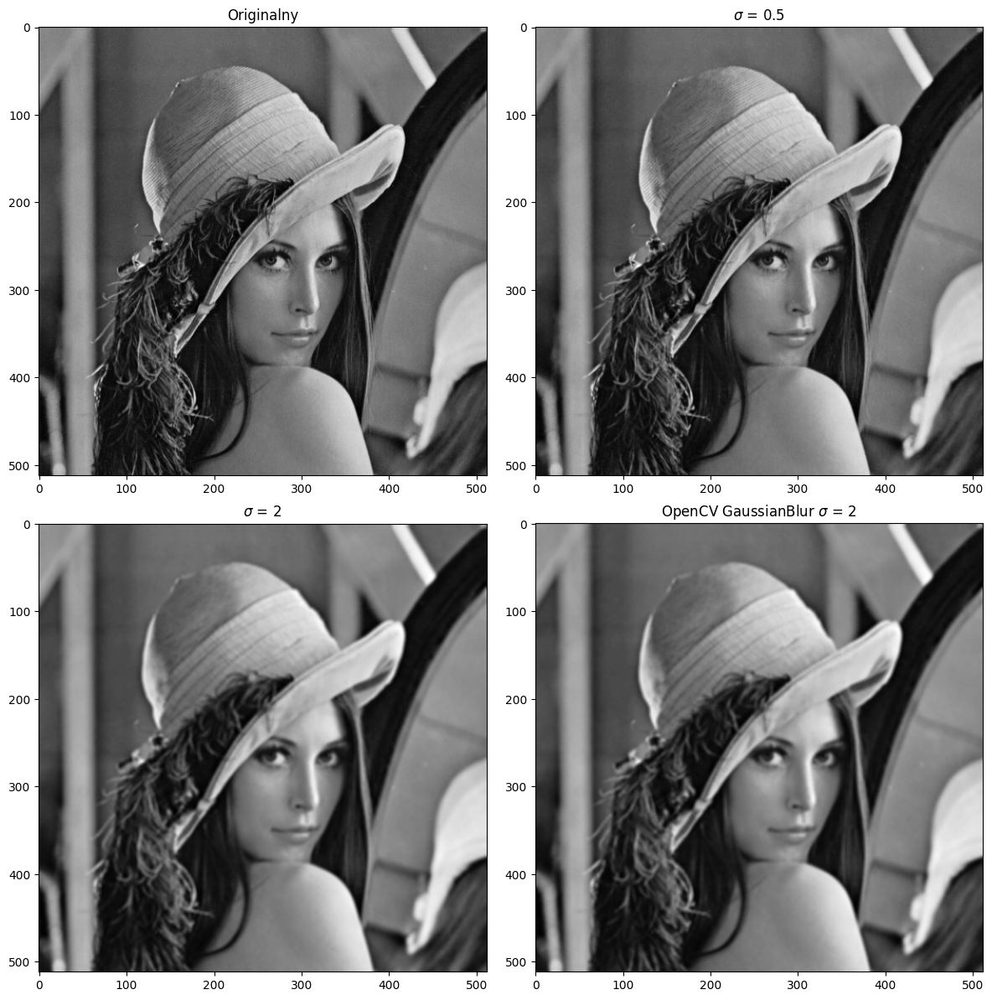

In [8]:
image = images["lena"]

f, axs = plt.subplots(2, 2)
axs = axs.flatten()
f.set_size_inches(12, 12)
f.tight_layout()
axs[0].set_title("Originalny")
axs[0].imshow(image, cmap="gray")
kernel = fgaussian(5, 0.5)
image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
axs[1].set_title(r"$\sigma$ = 0.5")
axs[1].imshow(image_filtered, cmap="gray")
kernel = fgaussian(5, 2)
image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
axs[2].set_title(r"$\sigma$ = 2")
axs[2].imshow(image_filtered, cmap="gray")
# OpenCV GaussianBlur
kernel_size = (5, 5)
image_filtered = cv2.GaussianBlur(image, kernel_size, 2)
axs[3].set_title(r"OpenCV GaussianBlur $\sigma$ = 2")
axs[3].imshow(image_filtered, cmap="gray")
plt.show()

### Filtry nieliniowe -- mediana

Filtry rozmywające redukują szum, ale niekorzystnie wpływają na ostrość obrazu.
Dlatego często wykorzystuje się filtry nieliniowe - np. filtr medianowy (dla przypomnienia: mediana - środkowa wartość w posortowanym ciągu liczb).

Podstawowa różnica pomiędzy filtrami liniowymi, a nieliniowymi polega na tym, że przy filtracji liniowej na nową wartość piksela ma wpływ wartość wszystkich pikseli z otoczenia (np. uśrednianie, czasem ważone), natomiast w przypadku filtracji nieliniowej jako nowy piksel wybierana jest któraś z wartości otoczenia - według jakiegoś wskaźnika (wartość największa, najmniejsza czy właśnie mediana).


1. Wczytaj obraz _lenaSzum.png_ (losowe 10% pikseli białych lub czarnych - tzw. zakłócenia impulsowe). Przeprowadź filtrację uśredniającą z rozmiarem maski 3x3. Wyświetl, podobnie jak wcześniej, oryginał, wynik filtracji i moduł z różnicy. Wykorzystując funkcję ``cv2.medianBlur` wykonaj filtrację medianową _lenaSzum.png_ (z rozmiarem maski $3 \times 3$). Wyświetl, podobnie jak wcześniej, oryginał, wynik filtracji i moduł z różnicy. Która filtracja lepiej radzi sobie z tego typu szumem?

  Uwaga. Taki sam efekt da również użycie funkcji `signal.medfilt2d`.


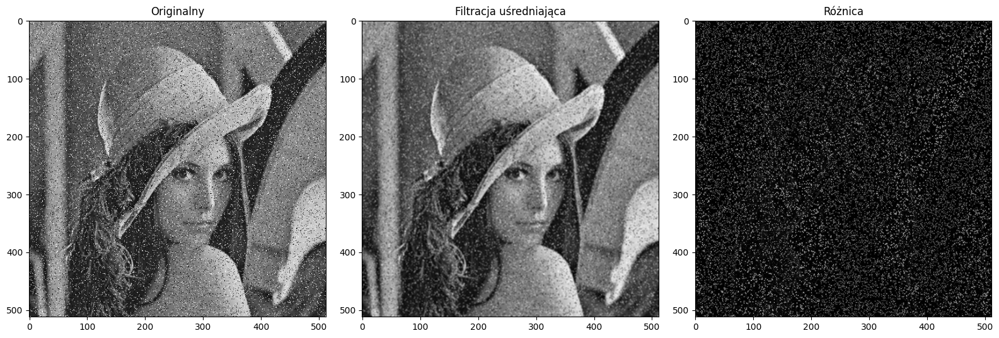

In [9]:
N = 3
image = images["lenaSzum"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
image_filtered = cv2.blur(image, (N, N))
image_diff = np.abs(
    cv2.subtract(image.astype("int16"), image_filtered.astype("int16"))
).astype("uint8")
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")
axs[1].imshow(image_filtered, cmap="gray")
axs[1].set_title("Filtracja uśredniająca")
axs[2].imshow(image_diff, cmap="gray")
axs[2].set_title("Różnica")
plt.show()

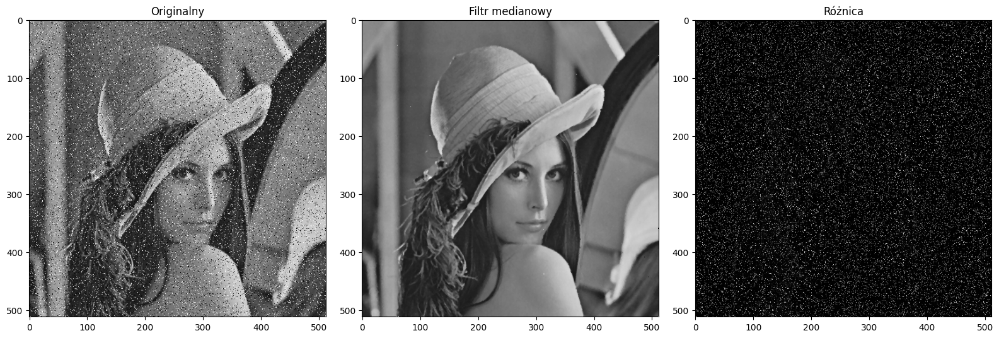

In [10]:
N = 3
image = images["lenaSzum"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
image_filtered = cv2.medianBlur(image, N)
image_diff = np.abs(
    cv2.subtract(image.astype("int16"), image_filtered.astype("int16"))
).astype("uint8")
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")
axs[1].imshow(image_filtered, cmap="gray")
axs[1].set_title("Filtr medianowy")
axs[2].imshow(image_diff, cmap="gray")
axs[2].set_title("Różnica")
plt.show()

2. Przeprowadź filtrację uśredniającą, a następnie medianową obrazu _lena.png_.
   Wyniki porównaj - dla obu wyświetl: oryginał, wynik filtracji i moduł z różnicy.
   Szczególną uwagę zwróć na ostrość i krawędzie.
   W której filtracji krawędzie zostają lepiej zachowane?

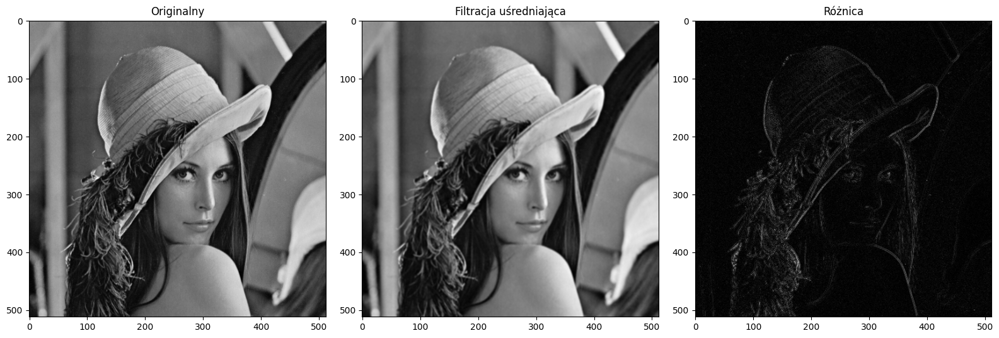

In [11]:
N = 3
image = images["lena"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
image_filtered = cv2.blur(image, (N, N))
image_diff = np.abs(
    cv2.subtract(image.astype("int16"), image_filtered.astype("int16"))
).astype("uint8")
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")
axs[1].imshow(image_filtered, cmap="gray")
axs[1].set_title("Filtracja uśredniająca")
axs[2].imshow(image_diff, cmap="gray")
axs[2].set_title("Różnica")
plt.show()

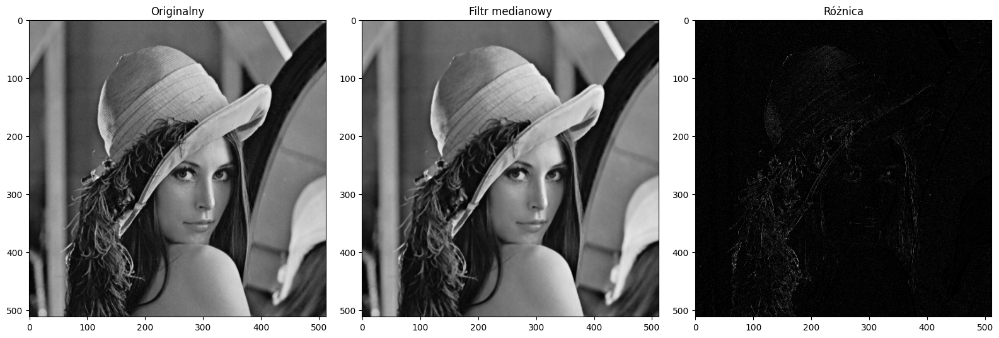

In [12]:
N = 3
image = images["lena"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
image_filtered = cv2.medianBlur(image, N)
image_diff = np.abs(
    cv2.subtract(image.astype("int16"), image_filtered.astype("int16"))
).astype("uint8")
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")
axs[1].imshow(image_filtered, cmap="gray")
axs[1].set_title("Filtr medianowy")
axs[2].imshow(image_diff, cmap="gray")
axs[2].set_title("Różnica")
plt.show()

3. Ciekawy efekt można uzyskać wykonując filtrację medianową wielokrotnie. Określa się go mianem  posteryzacji.  W wyniku przetwarzania z obrazka usunięte zostają detale, a duże obszary uzyskują tą samą wartość jasności.  Wykonaj operację mediany $5 \times 5$ na obrazie _lena.png_ 10-krotnie. (wykorzystaj np. pętlę `for`).


Inne filtry nieliniowe:
- filtr modowy - moda (dominanta) zamiast mediany,
- filtr olimpijski - średnia z podzbioru otoczenia (bez wartości ekstremalnych),
- hybrydowy filtr medianowy - mediana obliczana osobno w różnych podzbiorach otoczenia (np. kształt ``x'',``+''), a jako wynik brana jest mediana ze zbioru wartość elementu centralnego, mediana z ``x'' i mediana z ``+'',
- filtr minimalny i maksymalny (będą omówione przy okazji operacji morfologicznych w dalszej części kursu).


Warto zdawać sobie sprawę, z szerokich możliwości dopasowywania rodzaju filtracji do konkretnego rozważanego problemu i rodzaju zaszumienia występującego na obrazie.

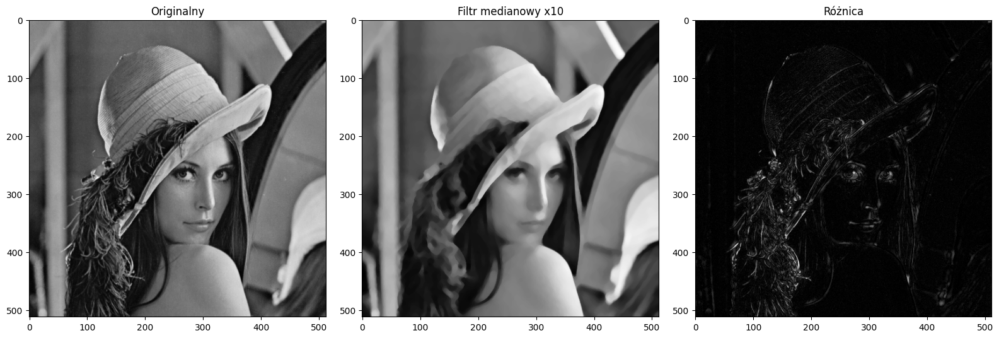

In [13]:
N = 5
image = images["lena"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
image_filtered = image
for _ in range(10):
    image_filtered = cv2.medianBlur(image_filtered, N)
image_diff = np.abs(
    cv2.subtract(image.astype("int16"), image_filtered.astype("int16"))
).astype("uint8")
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")
axs[1].imshow(image_filtered, cmap="gray")
axs[1].set_title("Filtr medianowy x10")
axs[2].imshow(image_diff, cmap="gray")
axs[2].set_title("Różnica")
plt.show()

## Filtry liniowe górnoprzepustowe (wyostrzające, wykrywające krawędzie)

Zadaniem filtrów górnoprzepustowych jest wydobywanie z obrazu składników odpowiedzialnych za szybkie zmiany jasności - konturów, krawędzi, drobnych elementów tekstury.

### Laplasjan (wykorzystanie drugiej pochodnej obrazu)

1. Wczytaj obraz _moon.png_.

2. Wprowadź podstawową maskę laplasjanu:
\begin{equation}
M = 
\begin{bmatrix}
0 & 1& 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0
\end{bmatrix}
\end{equation}

3. Przed rozpoczęciem obliczeń należy dokonać normalizacji maski - dla rozmiaru $3 \times 3$ podzielić każdy element przez 9.
   Proszę zwrócić uwagę, że nie można tu zastosować takiej samej normalizacji, jak dla filtrów dolnoprzepustowanych, gdyż skutkowałby to dzieleniem przez 0.

4. Wykonaj konwolucję obrazu z maską (`c2.filter2D`). Przed wyświetleniem, wynikowy obraz należy poddać normalizacji (występują ujemne wartości). Najczęściej wykonuje się jedną z dwóch operacji:
- skalowanie (np. poprzez dodatnie 128 do każdego z pikseli),
- moduł (wartość bezwzględna).

Wykonaj obie normalizacje. 
Na wspólnym wykresie wyświetl obraz oryginalny oraz przefiltrowany po obu normalizacjach. 

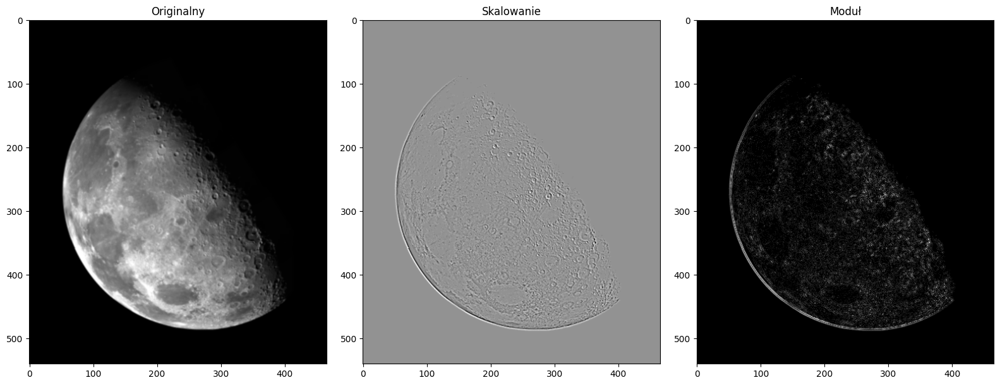

In [14]:
image = images["moon"]

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()
kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64) / 9
axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")
image_filtered = cv2.filter2D(src=image, ddepth=cv2.CV_16S, kernel=kernel)
image_filtered = cv2.normalize(
    src=image_filtered,
    dst=None,
    alpha=0,
    beta=255,
    norm_type=cv2.NORM_MINMAX,
    dtype=cv2.CV_8U,
)
axs[1].imshow(image_filtered, cmap="gray")
axs[1].set_title("Skalowanie")
image_filtered = cv2.filter2D(src=image, ddepth=cv2.CV_16S, kernel=kernel)
image_filtered = cv2.convertScaleAbs(image_filtered)
axs[2].imshow(image_filtered, cmap="gray")
axs[2].set_title("Moduł")
plt.show()

7. Efekt wyostrzenia uzyskuje się po odjęciu/dodaniu (zależy do maski) rezultatu filtracji laplasjanowej i oryginalnego obrazu. Wyświetl na jednym wykresie: obraz oryginalny, sumę oryginału i wyniku filtracji oraz różnicę (bezwzględną) oryginału i wyniku filtracji.
 Uwaga. Aby uniknąć artefaktów, należy obraz wejściowy przekonwertować do formatu ze znakiem.



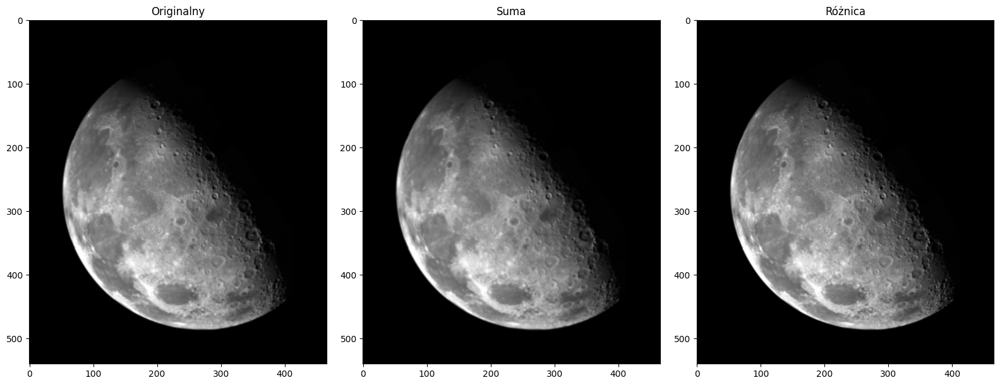

In [15]:
image = images["moon"].astype("int16")
kernel = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64) / 9

f, axs = plt.subplots(1, 3)
f.set_size_inches(16, 8)
f.tight_layout()

axs[0].imshow(image, cmap="gray")
axs[0].set_title("Originalny")

image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
axs[1].imshow(image + image_filtered, cmap="gray")
axs[1].set_title("Suma")

axs[2].imshow(np.abs(image - image_filtered), cmap="gray")
axs[2].set_title("Różnica")
plt.show()

### Gradienty (wykorzystanie pierwszej pochodnej obrazu)

1. Wczytaj obraz _kw.png_. Stwórz odpowiednie maski opisane w kolejnych punktach i dokonaj filtracji.
2. Wykorzystując gradient Robertsa przeprowadź detekcję krawędzi - poprzez wykonanie konwolucji obrazu z daną maską:
\begin{equation}
R1 = \begin{bmatrix} 0 & 0 & 0 \\ -1 & 0 & 0 \\ 0 & 1 & 0 \end{bmatrix}   
R2 = \begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0 \end{bmatrix}
\end{equation}

Wykorzystaj stworzony wcześniej kod (przy laplasjanie) - dwie metody normalizacji oraz sposób wyświetlania.

3. Analogicznie przeprowadź detekcję krawędzi za pomocą gradientu Prewitta (pionowy i poziomy)
\begin{equation}
P1 = \begin{bmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{bmatrix}   
P2 = \begin{bmatrix} -1 & -1 & -1 \\ 0 & 0 & 0 \\ 1 & 1 & 1 \end{bmatrix}
\end{equation}

4. Podobnie skonstruowany jest gradient Sobela (występuje osiem masek, zaprezentowane są dwie ``prostopadłe''):
\begin{equation}
S1 = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}   
S2 = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}
\end{equation}

Przeprowadź detekcję krawędzi za pomocą gradientu Sobela. 

In [16]:
def plot_gradient_filter(image, kernel, title):
    f, axs = plt.subplots(1, 3)
    f.set_size_inches(16, 8)
    f.tight_layout()

    axs[0].imshow(image, cmap="gray")
    axs[0].set_title("Originalny")

    image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
    image_filtered = cv2.normalize(
        src=image_filtered, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
    )
    axs[1].imshow(image_filtered, cmap="gray")
    axs[1].set_title(f"Skalowanie ({title})")

    image_filtered = cv2.filter2D(src=image, ddepth=-1, kernel=kernel)
    image_filtered = cv2.convertScaleAbs(image_filtered)
    axs[2].imshow(image_filtered, cmap="gray")
    axs[2].set_title(f"Moduł ({title})")
    plt.show()

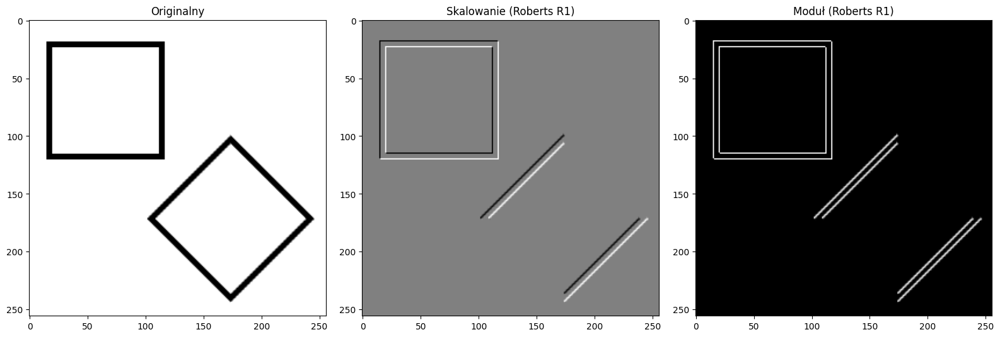

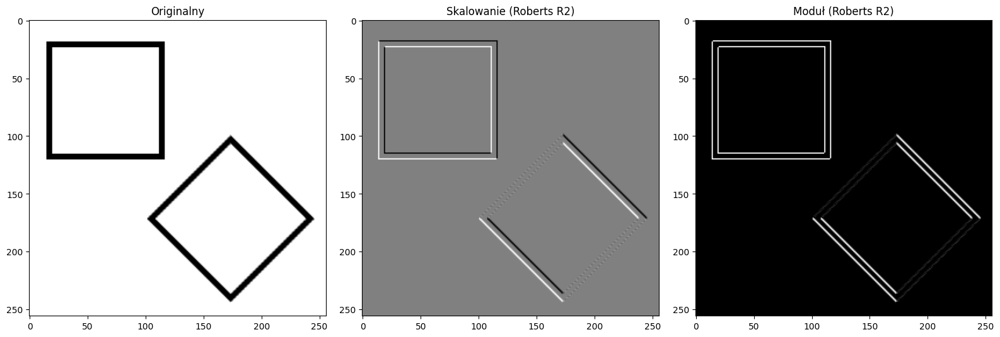

In [17]:
image = images["kw"].astype("int16")

R1 = np.array([[0, 0, 0], [-1, 0, 0], [0, 1, 0]], dtype=np.float64)
R2 = np.array([[0, 0, 0], [0, 0, -1], [0, 1, 0]], dtype=np.float64)
plot_gradient_filter(image, R1, "Roberts R1")
plot_gradient_filter(image, R2, "Roberts R2")

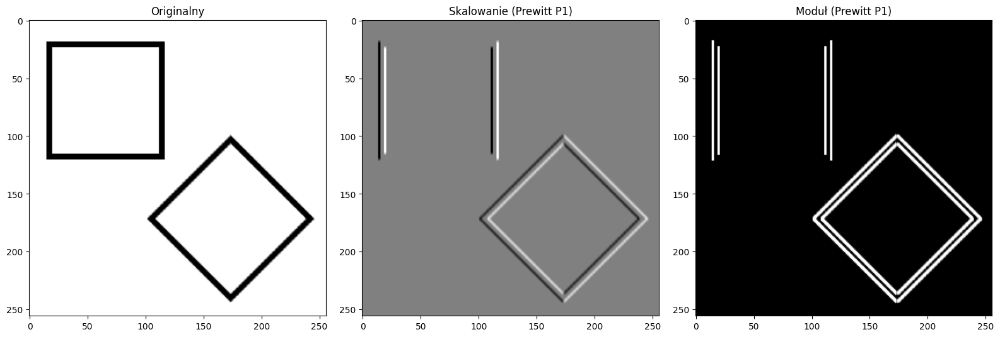

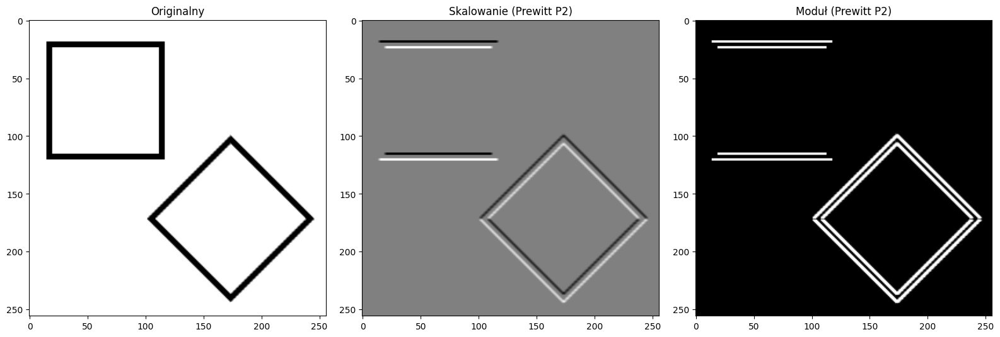

In [18]:
image = images["kw"].astype("int16")

P1 = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
P2 = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
plot_gradient_filter(image, P1, "Prewitt P1")
plot_gradient_filter(image, P2, "Prewitt P2")

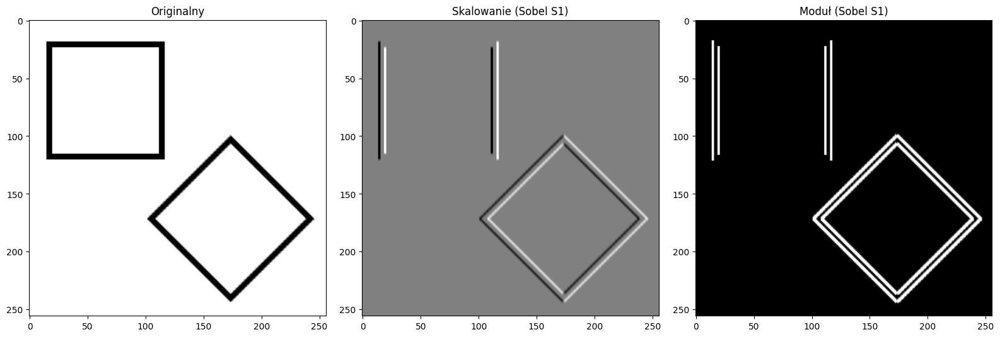

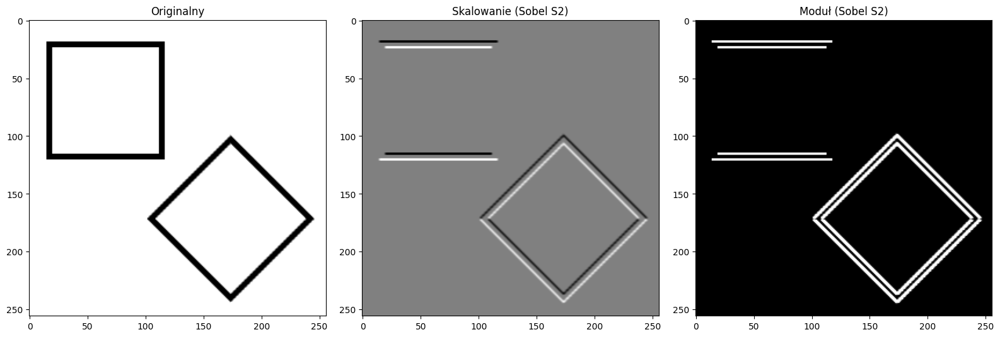

In [19]:
image = images["kw"].astype("int16")

S1 = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
S2 = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
plot_gradient_filter(image, S1, "Sobel S1")
plot_gradient_filter(image, S2, "Sobel S2")

5. Na podstawie dwóch ortogonalnych masek np. Sobela można stworzyć tzw. filtr kombinowany - pierwiastek kwadratowy z sumy kwadratów gradientów:
\begin{equation}
OW = \sqrt{(O * S1)^2 + (O * S2)^2}
\end{equation}
gdzie:  $OW$ - obraz wyjściowy, $O$ - obraz oryginalny (wejściowy), $S1,S2$ - maski Sobela, $*$ - operacja konwolucji.

Zaimplementuj filtr kombinowany.

Uwaga. Proszę zwrócić uwagę na konieczność zmiany formatu danych obrazu wejściowego - na typ znakiem



In [20]:
def plot_combination_filter_sqrt(image, kernel_1, kernel_2, title):
    f, axs = plt.subplots(1, 3)
    f.set_size_inches(16, 8)
    f.tight_layout()

    axs[0].imshow(image, cmap="gray")
    axs[0].set_title("Originalny")

    image_filtered_1 = cv2.filter2D(src=image, ddepth=-1, kernel=kernel_1)
    image_filtered_2 = cv2.filter2D(src=image, ddepth=-1, kernel=kernel_2)
    image_filtered = np.sqrt(image_filtered_1**2 + image_filtered_2**2)

    image_scaled = cv2.normalize(
        src=image_filtered, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
    )
    axs[1].imshow(image_scaled, cmap="gray")
    axs[1].set_title(f"Skalowanie ({title})")

    image_abs = cv2.convertScaleAbs(image_filtered)
    axs[2].imshow(image_abs, cmap="gray")
    axs[2].set_title(f"Moduł ({title})")
    plt.show()

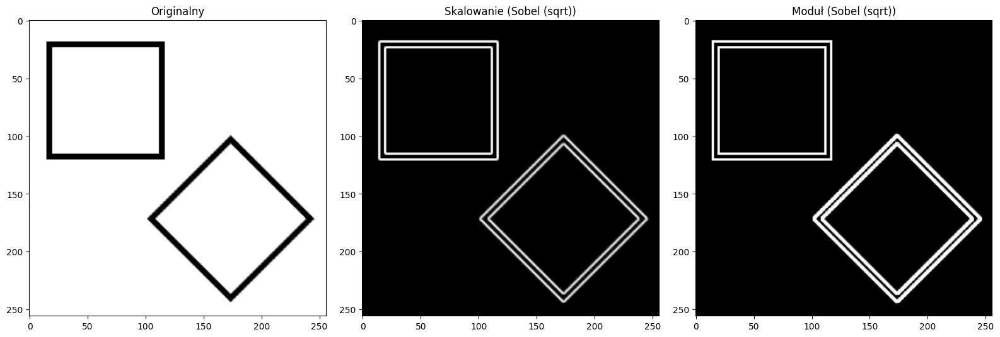

In [21]:
image = images["kw"].astype("float32")
plot_combination_filter_sqrt(image, S1, S2, "Sobel (sqrt)")

6. Istnieje alternatywna wersja filtra kombinowanego, która zamiast pierwiastka z sumy kwadratów wykorzystuje sumę modułów (prostsze obliczenia). 
Zaimplementuj tę wersję. 

In [22]:
def plot_combination_filter_abs(image, kernel_1, kernel_2, title):
    f, axs = plt.subplots(1, 3)
    f.set_size_inches(16, 8)
    f.tight_layout()

    axs[0].imshow(image, cmap="gray")
    axs[0].set_title("Originalny")

    image_filtered_1 = cv2.filter2D(src=image, ddepth=-1, kernel=kernel_1)
    image_filtered_2 = cv2.filter2D(src=image, ddepth=-1, kernel=kernel_2)
    image_filtered = np.abs(image_filtered_1) + np.abs(image_filtered_2)

    image_scaled = cv2.normalize(
        src=image_filtered, dst=None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
    )
    axs[1].imshow(image_scaled, cmap="gray")
    axs[1].set_title(f"Skalowanie ({title})")

    image_abs = cv2.convertScaleAbs(image_filtered)
    axs[2].imshow(image_abs, cmap="gray")
    axs[2].set_title(f"Moduł ({title})")
    plt.show()

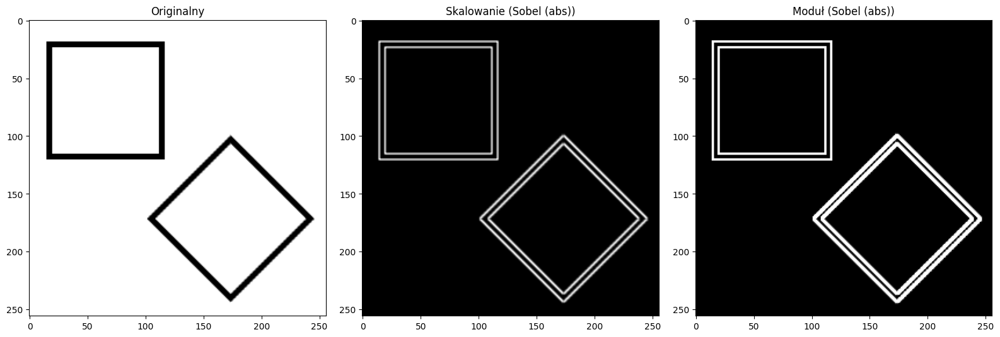

In [23]:
image = images["kw"].astype("float32")
plot_combination_filter_abs(image, S1, S2, "Sobel (abs)")

7. Wczytaj plik _jet.png_ (zamiast _kw.png_).
Sprawdź działanie obu wariantów filtracji kombinowanej.

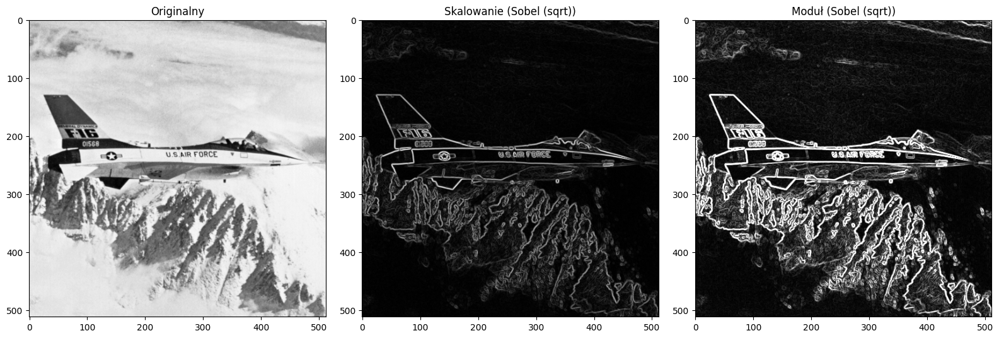

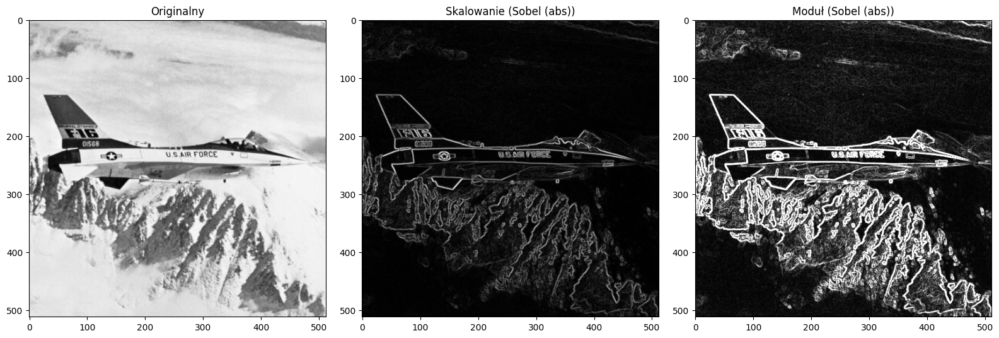

In [24]:
image = images["jet"].astype("float32")
plot_combination_filter_sqrt(image, S1, S2, "Sobel (sqrt)")
plot_combination_filter_abs(image, S1, S2, "Sobel (abs)")